In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import numpy as np
import torch
import yaml


In [2]:
path = Path('/home/obola/repositories/isca_emulation_v2/data/processed/gnn2d_coordinates_trig4_receiver_local_1000_to_3500_receiver_local_postprocessed_with_ssw')

train_tensor = torch.load(path / 'train_000.pt', map_location='cpu', weights_only=False)
val_tensor = torch.load(path / 'val_000.pt', map_location='cpu', weights_only=False)
test_tensor = torch.load(path / 'test_000.pt', map_location='cpu', weights_only=False)
stats_tensor = torch.load(path / 'stats.pt', map_location='cpu', weights_only=False)
with open(path / 'manifest.yaml', 'r', encoding='utf-8') as f:
    cfg = yaml.safe_load(f)

print(f'Loaded dataset: {cfg["dataset_name"]}')


Loaded dataset: gnn2d_coordinates_trig4_receiver_local_1000_to_3500_receiver_local_postprocessed_with_ssw


In [3]:
def _shape(x):
    return tuple(int(v) for v in x.shape)

for split_name, shard in [('train', train_tensor), ('val', val_tensor), ('test', test_tensor)]:
    print(f'\n{split_name.upper()} shard summary')
    print('x_dyn      ', _shape(shard.x_dyn), shard.x_dyn.dtype)
    print('node_static', _shape(shard.node_static), shard.node_static.dtype)
    print('edge_index ', _shape(shard.edge_index), shard.edge_index.dtype)
    print('edge_attr  ', _shape(shard.edge_attr), shard.edge_attr.dtype)



TRAIN shard summary
x_dyn       (2000, 8192, 180) torch.float32
node_static (8192, 4) torch.float32
edge_index  (2, 65536) torch.int64
edge_attr   (65536, 4) torch.float32

VAL shard summary
x_dyn       (250, 8192, 180) torch.float32
node_static (8192, 4) torch.float32
edge_index  (2, 65536) torch.int64
edge_attr   (65536, 4) torch.float32

TEST shard summary
x_dyn       (250, 8192, 180) torch.float32
node_static (8192, 4) torch.float32
edge_index  (2, 65536) torch.int64
edge_attr   (65536, 4) torch.float32


In [4]:
def check_shard(name, shard, cfg, stats):
    expected_t = int(cfg['split_shapes'][name][0])
    expected_n = int(cfg['graph']['num_nodes'])
    expected_e = int(cfg['graph']['num_edges'])
    expected_f = int(cfg['dynamic_features']['num_dynamic_features'])

    x_dyn = shard.x_dyn
    node_static = shard.node_static
    edge_index = shard.edge_index
    edge_attr = shard.edge_attr

    checks = []
    checks.append((x_dyn.ndim == 3, 'x_dyn is rank-3 [T, N, F]'))
    checks.append((x_dyn.shape[0] == expected_t, f'timesteps match manifest ({expected_t})'))
    checks.append((x_dyn.shape[1] == expected_n, f'num_nodes match manifest ({expected_n})'))
    checks.append((x_dyn.shape[2] == expected_f, f'num_features match manifest ({expected_f})'))
    checks.append((node_static.shape == (expected_n, 4), 'node_static shape is [N, 4]'))
    checks.append((edge_index.shape == (2, expected_e), f'edge_index shape is [2, {expected_e}]'))
    checks.append((edge_attr.shape[0] == expected_e, f'edge_attr has {expected_e} rows'))

    finite_ok = all(torch.isfinite(t).all().item() for t in [x_dyn, node_static, edge_attr])
    checks.append((finite_ok, 'x_dyn/node_static/edge_attr are finite'))

    checks.append((float(node_static.min()) >= -1.0001 and float(node_static.max()) <= 1.0001,
                   'node_static values are in [-1, 1]'))

    lat_norm_err = torch.abs(node_static[:, 0] ** 2 + node_static[:, 1] ** 2 - 1).max().item()
    lon_norm_err = torch.abs(node_static[:, 2] ** 2 + node_static[:, 3] ** 2 - 1).max().item()
    checks.append((lat_norm_err < 1e-4, f'lat trig pair has unit norm (max err={lat_norm_err:.2e})'))
    checks.append((lon_norm_err < 1e-4, f'lon trig pair has unit norm (max err={lon_norm_err:.2e})'))

    out_degree = torch.bincount(edge_index[0], minlength=expected_n)
    in_degree = torch.bincount(edge_index[1], minlength=expected_n)
    checks.append((torch.all(out_degree == 8).item(), 'every node has 8 outgoing edges'))

    # This reports whether each directed edge has its reverse. On this dataset,
    # most but not all edges are reciprocal due to the pole wrapping rule.
    edge_set = {(int(s), int(d)) for s, d in zip(edge_index[0].tolist(), edge_index[1].tolist())}
    missing_reverse = sum(1 for s, d in edge_set if (d, s) not in edge_set)
    checks.append((missing_reverse == 0, f'all directed edges are reciprocal (missing={missing_reverse})'))

    if edge_attr.shape[1] >= 3:
        dist = edge_attr[:, 2]
        checks.append((torch.all(dist > 0).item(), 'edge distance (radians) is strictly positive'))
        checks.append((torch.all(dist <= np.pi).item(), 'edge distance (radians) <= pi'))

    stats_ok = stats['mean'].shape[-3:] == (expected_f, 1, 1) and stats['std'].shape[-3:] == (expected_f, 1, 1)
    checks.append((stats_ok, 'stats mean/std shape aligns with feature count'))
    checks.append((torch.all(stats['std'] > 0).item(), 'stats std is positive'))

    print(f'\n{name.upper()} checks')
    for ok, msg in checks:
        status = 'OK' if ok else 'WARN'
        print(f'[{status}] {msg}')

    print(f'Out-degree unique values: {sorted(torch.unique(out_degree).tolist())}')
    vals, counts = torch.unique(in_degree, return_counts=True)
    indeg_hist = {int(v): int(c) for v, c in zip(vals, counts)}
    print(f'In-degree histogram: {indeg_hist}')


In [5]:
for split_name, shard in [('train', train_tensor), ('val', val_tensor), ('test', test_tensor)]:
    check_shard(split_name, shard, cfg, stats_tensor)



TRAIN checks
[OK] x_dyn is rank-3 [T, N, F]
[OK] timesteps match manifest (2000)
[OK] num_nodes match manifest (8192)
[OK] num_features match manifest (180)
[OK] node_static shape is [N, 4]
[OK] edge_index shape is [2, 65536]
[OK] edge_attr has 65536 rows
[WARN] x_dyn/node_static/edge_attr are finite
[OK] node_static values are in [-1, 1]
[OK] lat trig pair has unit norm (max err=1.19e-07)
[OK] lon trig pair has unit norm (max err=1.19e-07)
[OK] every node has 8 outgoing edges
[OK] all directed edges are reciprocal (missing=0)
[WARN] edge distance (radians) is strictly positive
[OK] edge distance (radians) <= pi
[OK] stats mean/std shape aligns with feature count
[OK] stats std is positive
Out-degree unique values: [8]
In-degree histogram: {8: 8192}

VAL checks
[OK] x_dyn is rank-3 [T, N, F]
[OK] timesteps match manifest (250)
[OK] num_nodes match manifest (8192)
[OK] num_features match manifest (180)
[OK] node_static shape is [N, 4]
[OK] edge_index shape is [2, 65536]
[OK] edge_attr 

In [6]:
# Quick physical sanity by variable block.
vars_cfg = cfg['dynamic_features']['vars']
levels = cfg['dynamic_features']['selected_levels']
n_levels = len(levels)

print(f'Variables: {vars_cfg}')
print(f'Levels per variable: {n_levels}')

x = train_tensor.x_dyn
for i, var_name in enumerate(vars_cfg):
    block = x[:, :, i * n_levels : (i + 1) * n_levels]
    # Use a lightweight sample for robust quantiles so this cell stays fast.
    sample = block[::20, ::32, :].reshape(-1)
    q01, q99 = torch.quantile(sample, torch.tensor([0.01, 0.99]))
    print(
        f'{var_name:>6} | mean={block.mean():8.3f} std={block.std():8.3f} '
        f'min={block.min():8.3f} max={block.max():8.3f} '
        f'p01(sample)={q01:8.3f} p99(sample)={q99:8.3f}'
    )


Variables: ['temp', 'ucomp', 'vcomp']
Levels per variable: 60
  temp | mean=     nan std=     nan min=     nan max=     nan p01(sample)= 179.942 p99(sample)= 294.401
 ucomp | mean=     nan std=     nan min=     nan max=     nan p01(sample)= -63.436 p99(sample)=  84.183
 vcomp | mean=     nan std=     nan min=     nan max=     nan p01(sample)= -36.011 p99(sample)=  36.462


In [7]:
def plot_feature_map(shard, cfg, var_name='temp', level_idx=0, time_idx=0, cmap='coolwarm'):
    vars_cfg = cfg['dynamic_features']['vars']
    levels = cfg['dynamic_features']['selected_levels']
    if var_name not in vars_cfg:
        raise ValueError(f'var_name must be one of {vars_cfg}')
    if not (0 <= level_idx < len(levels)):
        raise ValueError(f'level_idx must be in [0, {len(levels)-1}]')
    if not (0 <= time_idx < shard.x_dyn.shape[0]):
        raise ValueError(f'time_idx must be in [0, {shard.x_dyn.shape[0]-1}]')

    nlat = len(cfg['grid']['lat'])
    nlon = len(cfg['grid']['lon'])
    var_offset = vars_cfg.index(var_name) * len(levels)
    feat_idx = var_offset + level_idx

    field = shard.x_dyn[time_idx, :, feat_idx].reshape(nlat, nlon).cpu().numpy()

    fig, ax = plt.subplots(figsize=(10, 4))
    mesh = ax.pcolormesh(cfg['grid']['lon'], cfg['grid']['lat'], field, shading='auto', cmap=cmap)
    ax.set_title(f'{var_name} @ level={levels[level_idx]:.4g}, time_idx={time_idx}')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    fig.colorbar(mesh, ax=ax, label=var_name)
    plt.show()


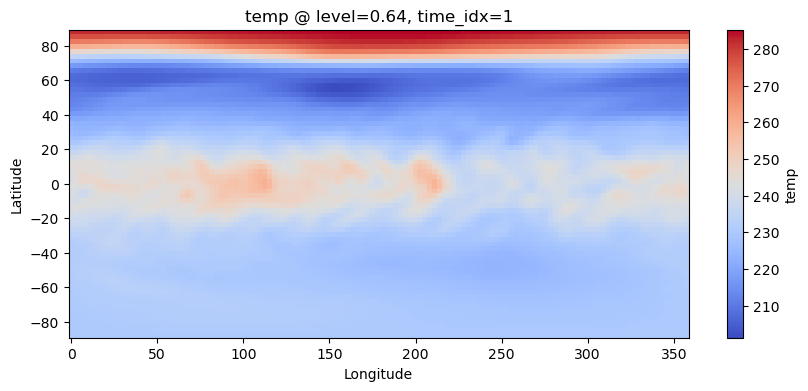

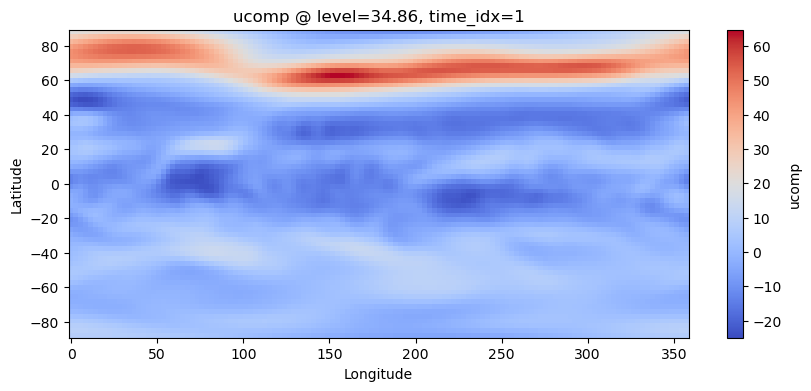

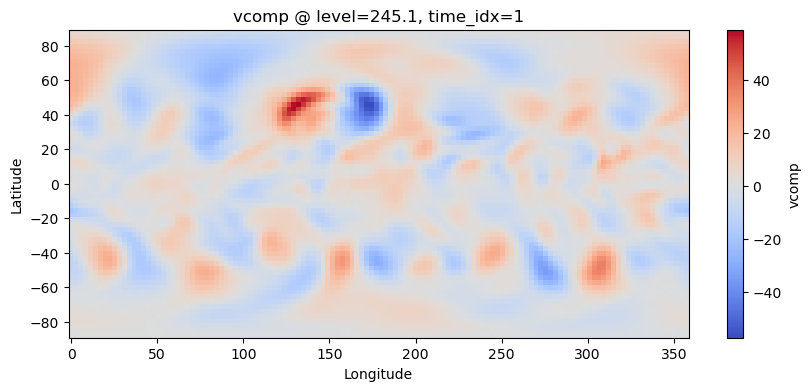

In [8]:
# Example visual checks (edit indices as needed):
plot_feature_map(train_tensor, cfg, var_name='temp', level_idx=10, time_idx=1)
plot_feature_map(train_tensor, cfg, var_name='ucomp', level_idx=30, time_idx=1)
plot_feature_map(train_tensor, cfg, var_name='vcomp', level_idx=45, time_idx=1)


In [9]:
def plot_graph_from_static(
    shard,
    *,
    max_edges=8000,
    node_size=4,
    node_alpha=0.8,
    edge_alpha=0.10,
    edge_width=0.3,
    seed=0,
):
    """Plot graph topology using only node_static and edge_index."""
    node_static = shard.node_static.detach().cpu().numpy()
    edge_index = shard.edge_index.detach().cpu().numpy()

    if node_static.shape[1] < 4:
        raise ValueError('node_static must contain [sin(lat), cos(lat), sin(lon), cos(lon)] features')

    lat = np.rad2deg(np.arctan2(node_static[:, 0], node_static[:, 1]))
    lon = np.rad2deg(np.arctan2(node_static[:, 2], node_static[:, 3]))
    lon = (lon + 360.0) % 360.0

    src = edge_index[0]
    dst = edge_index[1]
    n_edges = src.shape[0]
    if max_edges is not None and max_edges < n_edges:
        rng = np.random.default_rng(seed)
        keep = rng.choice(n_edges, size=max_edges, replace=False)
        src = src[keep]
        dst = dst[keep]

    x1 = lon[src]
    y1 = lat[src]
    x2 = lon[dst]
    y2 = lat[dst]

    # Draw shortest longitudinal segment when edges cross the 0/360 seam.
    dlon = x2 - x1
    x2 = np.where(dlon > 180.0, x2 - 360.0, x2)
    x2 = np.where(dlon < -180.0, x2 + 360.0, x2)

    segments = np.stack(
        [np.column_stack([x1, y1]), np.column_stack([x2, y2])],
        axis=1,
    )

    fig, ax = plt.subplots(figsize=(13, 4.5))
    lc = LineCollection(segments, colors='black', linewidths=edge_width, alpha=edge_alpha, zorder=1)
    ax.add_collection(lc)

    ax.scatter(lon, lat, s=node_size, c='tab:blue', alpha=node_alpha, linewidths=0, zorder=2)

    ax.set_xlim(-2, 362)
    ax.set_ylim(-92, 92)
    ax.set_xlabel('Longitude (deg)')
    ax.set_ylabel('Latitude (deg)')
    shown_edges = src.shape[0]
    ax.set_title(f'Graph from node_static + edge_index (nodes={lon.size}, edges shown={shown_edges})')
    ax.grid(True, linestyle=':', alpha=0.4)
    plt.show()


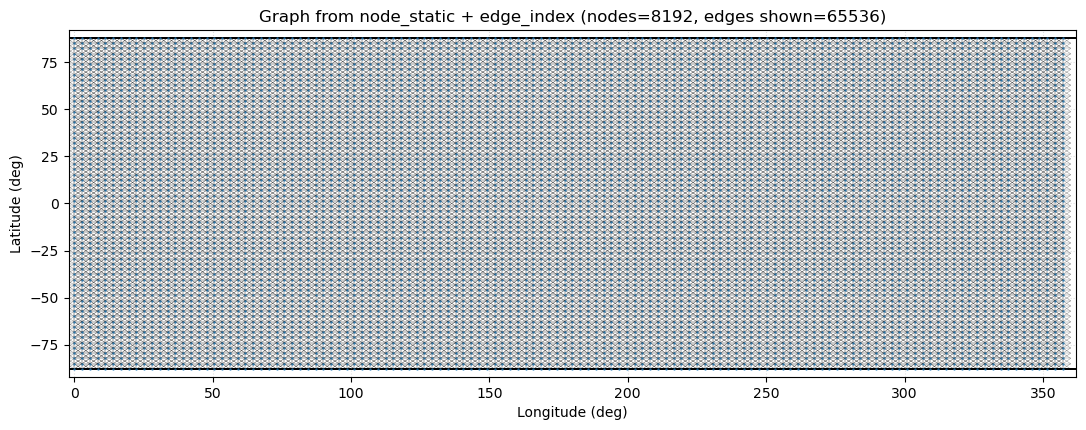

In [10]:
# Topology-only visual check (no x_dyn required).
plot_graph_from_static(train_tensor, max_edges=100000, node_size=3, edge_alpha=0.5)


In [11]:
import os
import yaml
import torch
import numpy as np
import plotly.graph_objects as go


def plot_gnn_grid_3d_interactive(
    root: str = "/home/obola/repositories/isca_emulation_v2/data/processed/gnn_coordinates_trig4_500_to_2000",
    split: str = "train",
    shard_idx: int = 0,
    max_edges: int = 4000,
    seed: int = 0,
    show_nodes: bool = True,
    node_size: int = 2,
    edge_width: float = 1.0,
    edge_opacity: float = 0.20,
    background_for_poster: bool = False,
    renderer: str | None = None,
):
    """Interactive 3D visualization of the processed GNN grid graph on a sphere."""
    manifest_path = os.path.join(root, "manifest.yaml")
    with open(manifest_path, "r", encoding="utf-8") as f:
        manifest = yaml.safe_load(f)

    shard_rel = manifest["split_shards"][split][shard_idx]["path"]
    shard_path = os.path.join(root, shard_rel)
    graph_data = torch.load(shard_path, map_location="cpu", weights_only=False)

    edge_index = graph_data.edge_index.cpu().numpy()      # [2, E]
    node_static = graph_data.node_static.cpu().numpy()    # [N, 4] = [sin(lat), cos(lat), sin(lon), cos(lon)]

    sin_lat, cos_lat, sin_lon, cos_lon = node_static.T
    lat = np.arctan2(sin_lat, cos_lat)
    lon = np.arctan2(sin_lon, cos_lon)

    # Unit sphere coordinates (single pfull level visualization)
    x = np.cos(lat) * np.cos(lon)
    y = np.cos(lat) * np.sin(lon)
    z = np.sin(lat)

    num_edges_total = edge_index.shape[1]
    n_edges = min(int(max_edges), int(num_edges_total))

    rng = np.random.default_rng(int(seed))
    if n_edges < num_edges_total:
        selected = rng.choice(num_edges_total, size=n_edges, replace=False)
    else:
        selected = np.arange(num_edges_total)

    src = edge_index[0, selected]
    dst = edge_index[1, selected]

    # Build edge line segments with NaN separators for Plotly
    x_edges = np.empty(n_edges * 3, dtype=np.float64)
    y_edges = np.empty(n_edges * 3, dtype=np.float64)
    z_edges = np.empty(n_edges * 3, dtype=np.float64)

    x_edges[0::3] = x[src]
    x_edges[1::3] = x[dst]
    x_edges[2::3] = np.nan
    y_edges[0::3] = y[src]
    y_edges[1::3] = y[dst]
    y_edges[2::3] = np.nan
    z_edges[0::3] = z[src]
    z_edges[1::3] = z[dst]
    z_edges[2::3] = np.nan

    if background_for_poster:
        background_rgb = np.array([47, 62, 234], dtype=np.float64) / 255.0
        tint = 0.9
        boxcolor = (1.0 - tint) * background_rgb + tint * np.ones(3, dtype=np.float64)
        boxcolor_255 = np.clip(np.round(boxcolor * 255.0), 0, 255).astype(int)
        figure_bgcolor = f"rgb({boxcolor_255[0]}, {boxcolor_255[1]}, {boxcolor_255[2]})"
    else:
        figure_bgcolor = "white"

    fig = go.Figure()

    fig.add_trace(
        go.Scatter3d(
            x=x_edges,
            y=y_edges,
            z=z_edges,
            mode="lines",
            line=dict(color="rgba(40, 40, 40, 1.0)", width=edge_width),
            opacity=edge_opacity,
            name=f"Edges ({n_edges}/{num_edges_total})",
            hoverinfo="skip",
        )
    )

    if show_nodes:
        fig.add_trace(
            go.Scatter3d(
                x=x,
                y=y,
                z=z,
                mode="markers",
                marker=dict(size=node_size, color=z, colorscale="Viridis", opacity=0.9),
                name=f"Nodes ({x.shape[0]})",
                hovertemplate="x=%{x:.3f}<br>y=%{y:.3f}<br>z=%{z:.3f}<extra></extra>",
            )
        )

    fig.update_layout(
        title=(
            "GNN Grid Graph on Sphere "
            f"(dataset={manifest['dataset_name']}, split={split}, shard={shard_idx})"
        ),
        scene=dict(
            xaxis=dict(visible=False),
            yaxis=dict(visible=False),
            zaxis=dict(visible=False),
            aspectmode="data",
            bgcolor=figure_bgcolor,
        ),
        paper_bgcolor=figure_bgcolor,
        width=900,
        height=900,
        margin=dict(l=0, r=0, t=60, b=0),
        legend=dict(yanchor="top", y=0.98, xanchor="left", x=0.02),
    )

    fig.show(renderer=renderer)
    return fig



In [13]:
# Example: interactive rotate/zoom of your processed GNN grid
_ = plot_gnn_grid_3d_interactive(
    root="/home/obola/repositories/isca_emulation_v2/data/processed/gnn2d_coordinates_trig4_receiver_local_1000_to_3500_receiver_local_postprocessed_with_ssw",
    split="train",
    shard_idx=0,
    max_edges=80000,
    seed=42,
    show_nodes=True,
    node_size=2,
    edge_width=1.0,
    edge_opacity=0.5,
    background_for_poster=False,
    renderer="browser",  # set to "notebook" if needed
)
